In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

RANDOM_STATE = 42

shopping = pd.read_csv("/Users/surbhichauhan/Desktop/online_shoppers_intention.csv")

churn = pd.read_csv("/Users/surbhichauhan/Desktop/E-commerce company/data_ecommerce_customer_churn.csv")

print("Online Shopping shape:", shopping.shape)
print("Customer Churn shape:", churn.shape)

display(shopping.head())
display(churn.head())

Online Shopping shape: (12330, 18)
Customer Churn shape: (3941, 11)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [23]:
print("ONLINE SHOPPING DATA")
print(shopping.info())

print("\nMissing values:")
print(shopping.isnull().sum())

print("\nExact duplicates:", shopping.duplicated().sum())

print("\nRevenue distribution:")
print(shopping["Revenue"].value_counts())
print(shopping["Revenue"].value_counts(normalize=True))


print("\n\nCUSTOMER CHURN DATA")
print(churn.info())

print("\nMissing values:")
print(churn.isnull().sum())

print("\nExact duplicates:", churn.duplicated().sum())

print("\nChurn distribution:")
print(churn["Churn"].value_counts())
print(churn["Churn"].value_counts(normalize=True))

ONLINE SHOPPING DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  T

In [25]:
shopping_clean = shopping.drop_duplicates().copy()
churn_clean = churn.drop_duplicates().copy()

print("Shopping after duplicate removal:", shopping_clean.shape)
print("Churn after duplicate removal:", churn_clean.shape)

print("\nShopping class distribution:")
print(shopping_clean["Revenue"].value_counts(normalize=True))

print("\nChurn class distribution:")
print(churn_clean["Churn"].value_counts(normalize=True))

Shopping after duplicate removal: (12205, 18)
Churn after duplicate removal: (3270, 11)

Shopping class distribution:
Revenue
False    0.843671
True     0.156329
Name: proportion, dtype: float64

Churn class distribution:
Churn
0    0.836697
1    0.163303
Name: proportion, dtype: float64


In [33]:
shopping_summary = shopping_clean.groupby("Revenue")[
    [
        "PageValues",
        "ExitRates",
        "BounceRates",
        "ProductRelated",
        "ProductRelated_Duration"
    ]
].mean()

print(shopping_summary)

         PageValues  ExitRates  BounceRates  ProductRelated  \
Revenue                                                       
False      1.999985   0.045526     0.023197       29.050403   
True      27.264518   0.019555     0.005117       48.210168   

         ProductRelated_Duration  
Revenue                           
False                1082.976881  
True                 1876.209615  


In [35]:
visitor_purchase = pd.crosstab(
    shopping_clean["VisitorType"],
    shopping_clean["Revenue"],
    normalize="index"
)

print(visitor_purchase)

Revenue               False     True 
VisitorType                          
New_Visitor        0.750738  0.249262
Other              0.802469  0.197531
Returning_Visitor  0.859074  0.140926


In [37]:
churn_summary = churn_clean.groupby("Churn")[
    [
        "Tenure",
        "WarehouseToHome",
        "SatisfactionScore",
        "NumberOfAddress",
        "DaySinceLastOrder",
        "CashbackAmount"
    ]
].mean()

print(churn_summary)

          Tenure  WarehouseToHome  SatisfactionScore  NumberOfAddress  \
Churn                                                                   
0      11.488186        15.236961           2.960161         4.169225   
1       3.183128        16.989775           3.331461         4.498127   

       DaySinceLastOrder  CashbackAmount  
Churn                                     
0               4.786847      180.717007  
1               3.307540      160.513202  


In [39]:
complaint_churn = pd.crosstab(
    churn_clean["Complain"],
    churn_clean["Churn"],
    normalize="index"
)

print(complaint_churn)

Churn            0         1
Complain                    
0         0.897403  0.102597
1         0.681868  0.318132


In [41]:
shopping_target = "Revenue"

shopping_categorical = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

X_shopping = shopping_clean.drop(columns=[shopping_target])
y_shopping = shopping_clean[shopping_target].astype(int)

shopping_numeric = [
    col for col in X_shopping.columns
    if col not in shopping_categorical
]

print("Numeric features:")
print(shopping_numeric)

print("\nCategorical features:")
print(shopping_categorical)

Numeric features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

Categorical features:
['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']


In [43]:
churn_target = "Churn"

churn_categorical = [
    "PreferedOrderCat",
    "MaritalStatus",
    "Complain"
]

X_churn = churn_clean.drop(columns=[churn_target])
y_churn = churn_clean[churn_target].astype(int)

churn_numeric = [
    col for col in X_churn.columns
    if col not in churn_categorical
]

print("Numeric features:")
print(churn_numeric)

print("\nCategorical features:")
print(churn_categorical)

Numeric features:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'DaySinceLastOrder', 'CashbackAmount']

Categorical features:
['PreferedOrderCat', 'MaritalStatus', 'Complain']


In [58]:
def create_preprocessor(numeric_features, categorical_features):

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    return preprocessor

In [60]:
X_shop_train, X_shop_test, y_shop_train, y_shop_test = train_test_split(
    X_shopping,
    y_shopping,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_shopping
)

X_churn_train, X_churn_test, y_churn_train, y_churn_test = train_test_split(
    X_churn,
    y_churn,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_churn
)

print("Shopping training:", X_shop_train.shape)
print("Shopping testing:", X_shop_test.shape)

print("Churn training:", X_churn_train.shape)
print("Churn testing:", X_churn_test.shape)

Shopping training: (9764, 17)
Shopping testing: (2441, 17)
Churn training: (2616, 10)
Churn testing: (654, 10)


In [62]:
def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities)
    }

    print(model_name)
    print("=" * 50)

    print(classification_report(y_test, predictions))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    print("ROC-AUC:", results["ROC-AUC"])
    print("PR-AUC:", results["PR-AUC"])

    return results

In [64]:
shopping_preprocessor_lr = create_preprocessor(
    shopping_numeric,
    shopping_categorical
)

shopping_lr = Pipeline([
    ("preprocessor", shopping_preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

shopping_lr.fit(X_shop_train, y_shop_train)

shopping_lr_results = evaluate_model(
    shopping_lr,
    X_shop_test,
    y_shop_test,
    "Shopping - Logistic Regression"
)

Shopping - Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.86      0.90      2059
           1       0.50      0.80      0.62       382

    accuracy                           0.85      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.85      0.86      2441

Confusion Matrix:
[[1761  298]
 [  78  304]]
ROC-AUC: 0.9096572575005912
PR-AUC: 0.662707917912234


In [66]:
shopping_preprocessor_rf = create_preprocessor(
    shopping_numeric,
    shopping_categorical
)

shopping_rf = Pipeline([
    ("preprocessor", shopping_preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

shopping_rf.fit(X_shop_train, y_shop_train)

shopping_rf_results = evaluate_model(
    shopping_rf,
    X_shop_test,
    y_shop_test,
    "Shopping - Random Forest"
)

Shopping - Random Forest
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2059
           1       0.67      0.68      0.68       382

    accuracy                           0.90      2441
   macro avg       0.81      0.81      0.81      2441
weighted avg       0.90      0.90      0.90      2441

Confusion Matrix:
[[1934  125]
 [ 123  259]]
ROC-AUC: 0.9284916939804562
PR-AUC: 0.7367946696653463


In [68]:
churn_preprocessor_lr = create_preprocessor(
    churn_numeric,
    churn_categorical
)

churn_lr = Pipeline([
    ("preprocessor", churn_preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

churn_lr.fit(X_churn_train, y_churn_train)

churn_lr_results = evaluate_model(
    churn_lr,
    X_churn_test,
    y_churn_test,
    "Churn - Logistic Regression"
)

Churn - Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.76      0.86       547
           1       0.43      0.90      0.58       107

    accuracy                           0.79       654
   macro avg       0.70      0.83      0.72       654
weighted avg       0.88      0.79      0.81       654

Confusion Matrix:
[[418 129]
 [ 11  96]]
ROC-AUC: 0.9190828478190299
PR-AUC: 0.7067063905704216


In [70]:
churn_preprocessor_rf = create_preprocessor(
    churn_numeric,
    churn_categorical
)

churn_rf = Pipeline([
    ("preprocessor", churn_preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

churn_rf.fit(X_churn_train, y_churn_train)

churn_rf_results = evaluate_model(
    churn_rf,
    X_churn_test,
    y_churn_test,
    "Churn - Random Forest"
)

Churn - Random Forest
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       547
           1       0.72      0.79      0.75       107

    accuracy                           0.92       654
   macro avg       0.84      0.86      0.85       654
weighted avg       0.92      0.92      0.92       654

Confusion Matrix:
[[515  32]
 [ 23  84]]
ROC-AUC: 0.9521092108185686
PR-AUC: 0.7438357431044563


In [72]:
results_df = pd.DataFrame([
    shopping_lr_results,
    shopping_rf_results,
    churn_lr_results,
    churn_rf_results
])

results_df = results_df.round(3)

display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Shopping - Logistic Regression,0.846,0.505,0.796,0.618,0.910,0.663
1,Shopping - Random Forest,0.898,0.674,0.678,0.676,0.928,0.737
2,Churn - Logistic Regression,0.786,0.427,0.897,0.578,0.919,0.707
3,Churn - Random Forest,0.916,0.724,0.785,0.753,0.952,0.744


In [74]:
def get_feature_importance(pipeline, top_n=10):

    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["classifier"]

    feature_names = preprocessor.get_feature_names_out()
    importance = model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(
        "Importance",
        ascending=False
    )

    return importance_df.head(top_n)

In [76]:
shopping_importance = get_feature_importance(
    shopping_rf,
    top_n=10
)

display(shopping_importance)

,Feature,Importance
8,num__PageValues,0.370968
7,num__ExitRates,0.093892
5,num__ProductRelated_Duration,0.079060
4,num__ProductRelated,0.063879
6,num__BounceRates,0.052172
1,num__Administrative_Duration,0.045729
0,num__Administrative,0.039762
17,cat__Month_Nov,0.028652
3,num__Informational_Duration,0.019684
2,num__Informational,0.013817


In [78]:
churn_importance = get_feature_importance(
    churn_rf,
    top_n=10
)

display(churn_importance)

,Feature,Importance
0,num__Tenure,0.316363
6,num__CashbackAmount,0.148530
1,num__WarehouseToHome,0.083550
5,num__DaySinceLastOrder,0.069459
4,num__NumberOfAddress,0.067172
3,num__SatisfactionScore,0.063222
17,cat__Complain_1,0.047023
16,cat__Complain_0,0.046668
2,num__NumberOfDeviceRegistered,0.033390
15,cat__MaritalStatus_Single,0.025374


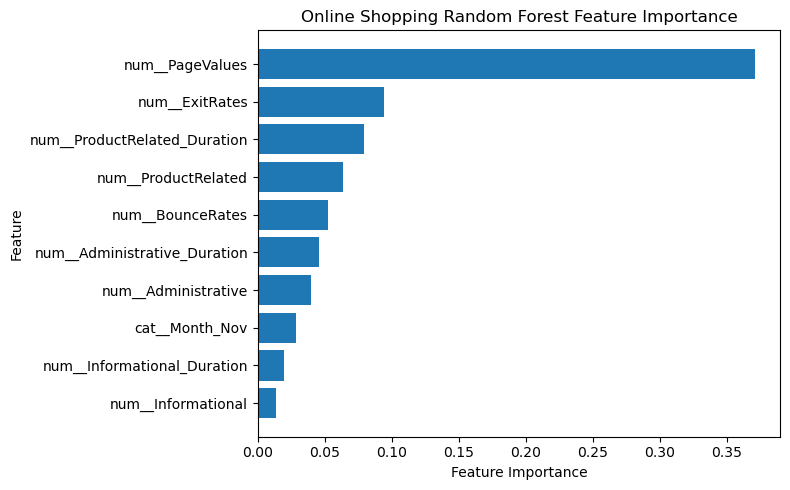

In [88]:
plt.figure(figsize=(8, 5))

plot_data = shopping_importance.sort_values("Importance")

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Online Shopping Random Forest Feature Importance")

plt.tight_layout()
plt.savefig(
    "shopping_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

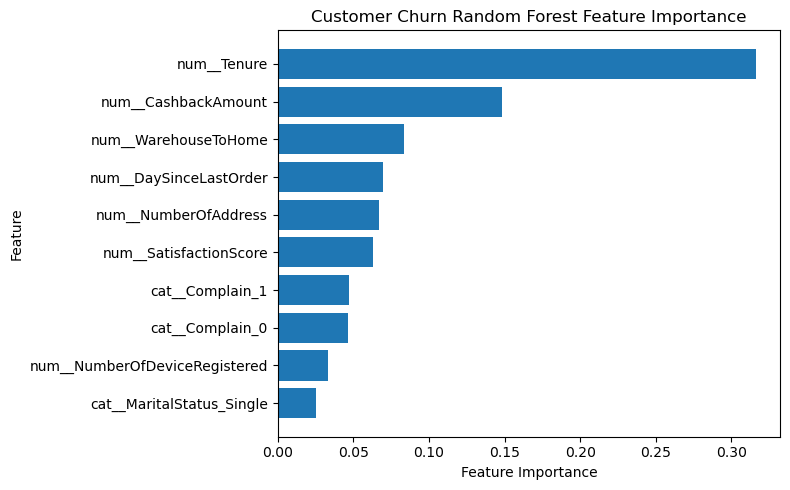

In [90]:
plt.figure(figsize=(8, 5))

plot_data = churn_importance.sort_values("Importance")

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Customer Churn Random Forest Feature Importance")

plt.tight_layout()
plt.savefig(
    "churn_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
# Create results dataframe

results_df = pd.DataFrame([
    shopping_lr_results,
    shopping_rf_results,
    churn_lr_results,
    churn_rf_results
])

results_df = results_df.round(3)

display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Shopping - Logistic Regression,0.846,0.505,0.796,0.618,0.910,0.663
1,Shopping - Random Forest,0.898,0.674,0.678,0.676,0.928,0.737
2,Churn - Logistic Regression,0.786,0.427,0.897,0.578,0.919,0.707
3,Churn - Random Forest,0.916,0.724,0.785,0.753,0.952,0.744


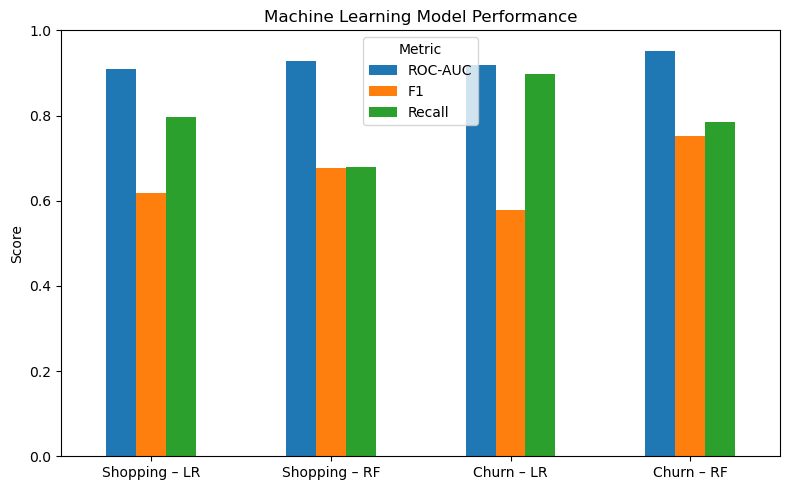

In [118]:
plot_results = results_df.copy()

plot_results["Model"] = [
    "Shopping – LR",
    "Shopping – RF",
    "Churn – LR",
    "Churn – RF"
]

plot_results = plot_results.set_index("Model")[
    ["ROC-AUC", "F1", "Recall"]
]

ax = plot_results.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Machine Learning Model Performance")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

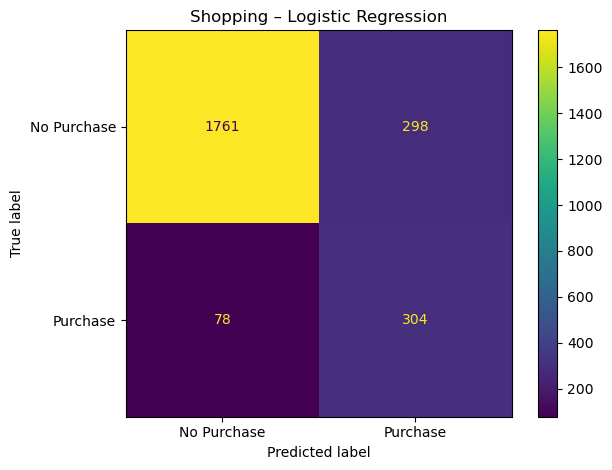

In [96]:
from sklearn.metrics import ConfusionMatrixDisplay

shopping_lr_pred = shopping_lr.predict(X_shop_test)

ConfusionMatrixDisplay.from_predictions(
    y_shop_test,
    shopping_lr_pred,
    display_labels=["No Purchase", "Purchase"],
    values_format="d"
)

plt.title("Shopping – Logistic Regression")
plt.tight_layout()

plt.savefig(
    "shopping_lr_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

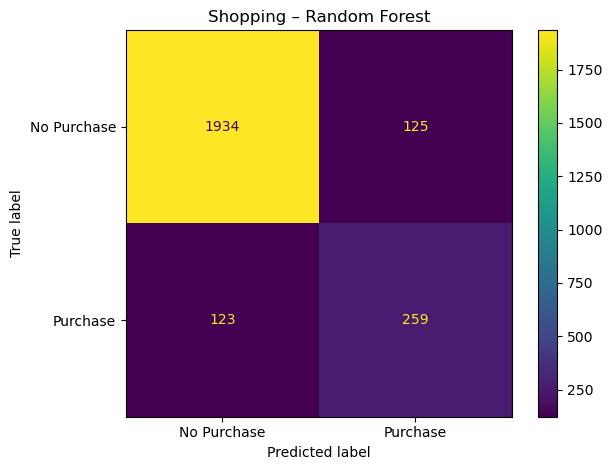

In [98]:
shopping_rf_pred = shopping_rf.predict(X_shop_test)

ConfusionMatrixDisplay.from_predictions(
    y_shop_test,
    shopping_rf_pred,
    display_labels=["No Purchase", "Purchase"],
    values_format="d"
)

plt.title("Shopping – Random Forest")
plt.tight_layout()

plt.savefig(
    "shopping_rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

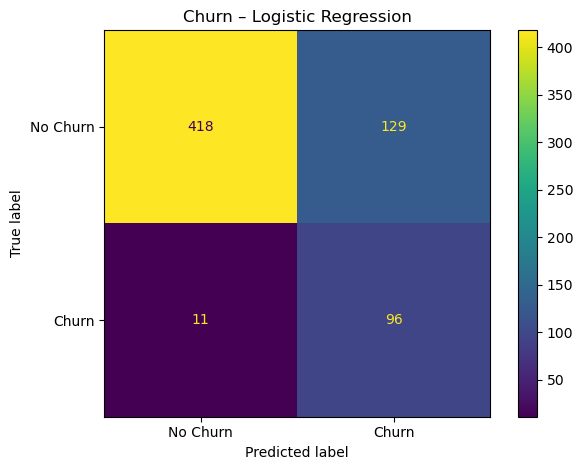

In [100]:
churn_lr_pred = churn_lr.predict(X_churn_test)

ConfusionMatrixDisplay.from_predictions(
    y_churn_test,
    churn_lr_pred,
    display_labels=["No Churn", "Churn"],
    values_format="d"
)

plt.title("Churn – Logistic Regression")
plt.tight_layout()

plt.savefig(
    "churn_lr_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

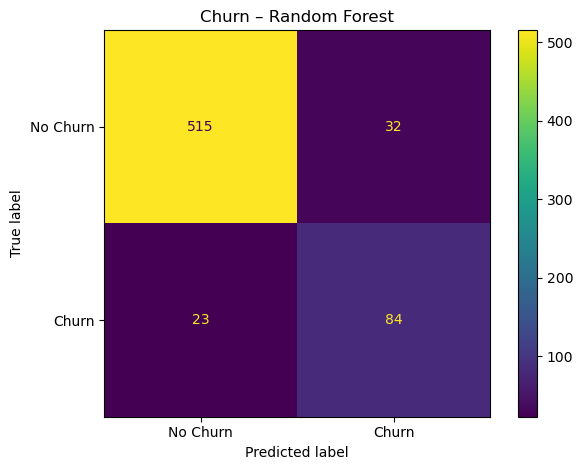

In [102]:
churn_rf_pred = churn_rf.predict(X_churn_test)

ConfusionMatrixDisplay.from_predictions(
    y_churn_test,
    churn_rf_pred,
    display_labels=["No Churn", "Churn"],
    values_format="d"
)

plt.title("Churn – Random Forest")
plt.tight_layout()

plt.savefig(
    "churn_rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

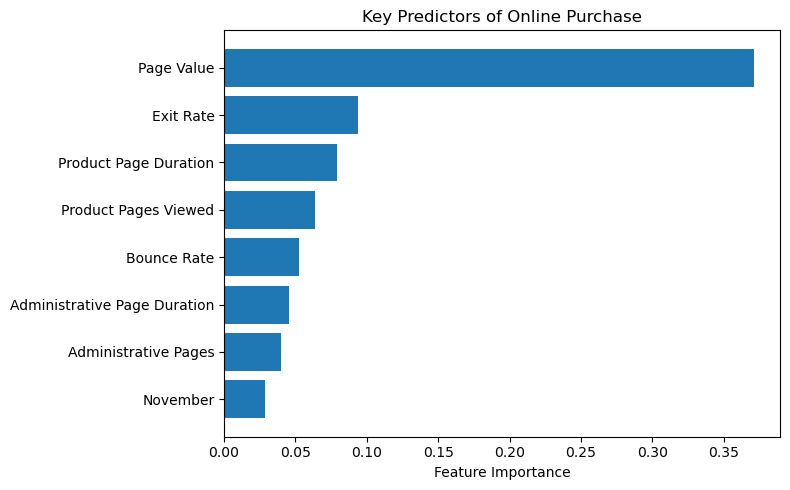

In [122]:
shopping_plot = shopping_importance.copy()

# Remove preprocessing prefixes
shopping_plot["Feature"] = (
    shopping_plot["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Rename features for readability
feature_names = {
    "PageValues": "Page Value",
    "ExitRates": "Exit Rate",
    "ProductRelated_Duration": "Product Page Duration",
    "ProductRelated": "Product Pages Viewed",
    "BounceRates": "Bounce Rate",
    "Administrative_Duration": "Administrative Page Duration",
    "Administrative": "Administrative Pages",
    "Month_Nov": "November"
}

shopping_plot["Feature"] = shopping_plot["Feature"].replace(feature_names)

# Select the top 8 features
plot_data = shopping_plot.head(8).sort_values("Importance")

# Plot
plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("")
plt.title("Key Predictors of Online Purchase")

plt.tight_layout()

plt.savefig(
    "shopping_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

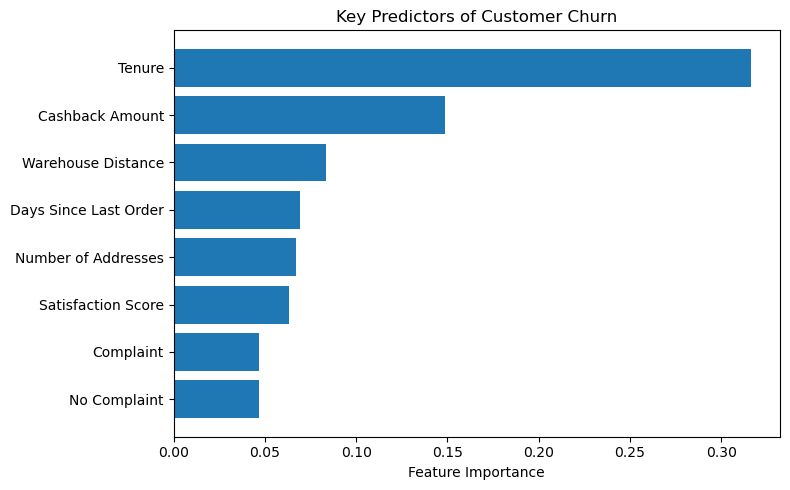

In [120]:
churn_plot = churn_importance.copy()

churn_plot["Feature"] = (
    churn_plot["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_names = {
    "Tenure": "Tenure",
    "CashbackAmount": "Cashback Amount",
    "WarehouseToHome": "Warehouse Distance",
    "DaySinceLastOrder": "Days Since Last Order",
    "NumberOfAddress": "Number of Addresses",
    "SatisfactionScore": "Satisfaction Score",
    "Complain_1": "Complaint",
    "Complain_0": "No Complaint",
    "NumberOfDeviceRegistered": "Devices Registered",
    "MaritalStatus_Single": "Single"
}

churn_plot["Feature"] = churn_plot["Feature"].replace(feature_names)

plot_data = churn_plot.head(8).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("")
plt.title("Key Predictors of Customer Churn")

plt.tight_layout()

plt.savefig(
    "churn_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [113]:
import os

print(os.getcwd())

/Users/surbhichauhan/Desktop


In [115]:
print([
    file for file in os.listdir()
    if file.endswith(".png")
])

['shopping_feature_importance.png', 'ChatGPT Image May 6, 2026, 05_30_39 PM.png', 'Screenshot 2026-06-04 at 1.38.42\u202fPM.png', 'Screenshot 2026-05-02 at 11.26.18\u202fPM.png', 'rmit-wordmark-white.png', 'ChatGPT Image Jul 25, 2026, 08_25_15 PM.png', 'Screenshot 2026-05-21 at 10.54.09\u202fPM.png', 'Screenshot 2026-05-01 at 10.27.14\u202fPM.png', 'diagram_pro.png', 'Screenshot 2026-05-01 at 9.33.17\u202fPM.png', 'shopping_lr_confusion_matrix.png', 'Screenshot 2026-05-21 at 12.26.14\u202fAM.png', 'churn_rf_confusion_matrix.png', 'Screenshot 2026-06-04 at 5.45.26\u202fPM.png', 'background.png', 'Screenshot 2026-05-28 at 1.09.24\u202fPM.png', 'Screenshot 2026-05-29 at 10.28.15\u202fAM.png', 'logo 5.png', 'logo 4.png', 'logo.png', 'churn_feature_importance.png', 'ai model.png', 'logo 3.png', 'Screenshot 2026-07-26 at 5.40.31\u202fPM.png', 'logo 2.png', 'churn_lr_confusion_matrix.png', 'Screenshot 2026-08-01 at 9.19.37\u202fPM.png', 'logo 1.png', 'diagram_pro (1).png', 'shopping_rf_confus